# Figure 11 from a genuine full-SU(2) circuit

**Manuscript map.** Sec. III G 2, Fig. 11, Eq. (79).

This notebook computes the curves from 100 raw circuit
realizations at the paper size $N_s=8,N_e=12$. Every gate is an
isotropic-exchange (partial-SWAP) gate, the environment is a
product of singlets and is never reset, and the asymmetry uses the
exact SU(2) Haar twirl over every total-spin irrep.

This is not the Liu/U(1) construction. We explicitly test
covariance under all three noncommuting generators
$S_x,S_y,S_z$ before plotting any result.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_TOOLS_DIR = (Path.cwd() / "tools").resolve()
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import circuit_data as cd
import notebook_utils as nu

np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GOLD = "#F4C95D"
PALETTE_3 = [BLUE, ORANGE, GOLD]
PALETTE_5 = plt.cm.Oranges(np.linspace(0.35, 0.95, 5))


def load_npz(path):
    with np.load(path, allow_pickle=False) as stored:
        return {name: stored[name] for name in stored.files}


## 1. Load the raw full-SU(2) ensemble

The NPZ contains every per-realization trajectory and every
isotropic coupling used in the run. It can be regenerated with:

```bash
python tools/generate_circuit_data.py --only su2-fig11 --paper-scale
```

The simulator evolves two fixed-magnetization sectors only as an
exact block decomposition of the same $2^{20}$-dimensional
partial-SWAP circuit. No U(1) channel, dephasing surrogate, or
fitted decay law is involved.


In [2]:
DATA_PATH = Path(
    "data/circuit_examples/su2_fig11_full_su2.npz"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} is missing. Run "
        "`python tools/generate_circuit_data.py "
        "--only su2-fig11 --paper-scale`."
    )

data = load_npz(DATA_PATH)
raw_asymmetry = data["asymmetry"]
mean_asymmetry = raw_asymmetry.mean(axis=0)
sem_asymmetry = raw_asymmetry.std(
    axis=0, ddof=1
) / np.sqrt(raw_asymmetry.shape[0])
displayed_time = data["displayed_times"]
theta_over_pi = np.array([0.30, 0.35, 0.40, 0.45, 0.50])
labels = [
    fr"${theta:.2f}\,\pi$" for theta in theta_over_pi
]

print(data["protocol"].item())
print(data["data_level"].item())
print(
    f"Ns={data['n_system'].item()}, "
    f"Ne={data['n_environment'].item()}, "
    f"realizations={data['n_realizations'].item()}"
)
print("raw trajectory array:", raw_asymmetry.shape)
print("gate family:", data["gate_family"].item())
print("environment:", data["environment"].item())
print("state convention:", data["state_definition"].item())
print("time calibration:", data["time_calibration"].item())

assert raw_asymmetry.shape[0] == 100
assert raw_asymmetry.shape[1] == 5
assert raw_asymmetry.shape[2] == len(displayed_time)
assert np.all(np.isfinite(raw_asymmetry))
assert data["gate_family"].item().endswith(
    "exact full SU(2)"
)


Fig. 11 full-SU(2) non-Markovian periodic brickwork ensemble
raw per-realization full-SU(2) simulation
Ns=8, Ne=12, realizations=100
raw trajectory array: (100, 5, 61)
gate family: isotropic exchange / partial SWAP; exact full SU(2)
environment: product of singlets; no reset
state convention: cos((theta+pi/2)/2)|singlets> + sin((theta+pi/2)/2)|0...0>
time calibration: displayed_time = 0.1 + 0.2*(Floquet_layer - 1)


## 2. Verify full SU(2), not merely U(1)

An isotropic two-spin gate has the form

$$
U_J=\cos(J/2)I-i\sin(J/2)\,\mathrm{SWAP}.
$$

Full SU(2) covariance requires it to commute independently with
$S_x^{(1)}+S_x^{(2)}$, $S_y^{(1)}+S_y^{(2)}$, and
$S_z^{(1)}+S_z^{(2)}$. Checking only the last commutator would
establish U(1), not SU(2).

We also verify that the singlet bath is invariant and that the
exact Clebsch--Gordan twirl commutes with all three collective
system generators. The twirl retains multiplicity coherences and
depolarizes each spin-$j$ irrep; it is not a magnetization
dephasing map.


In [3]:
representative_coupling = float(data["couplings"][0, 0])
gate = nu.su2_gate(representative_coupling)
two_spin_generators = nu.collective_spin(2)
gate_commutators = np.array([
    la.norm(gate @ generator - generator @ gate)
    for generator in two_spin_generators
])

two_spin_singlet = nu.singlet_product(2)
bath_invariance = np.array([
    la.norm(generator @ two_spin_singlet)
    for generator in two_spin_generators
])

# The production run uses exact symmetry-sector compression.
# Check that implementation against a dense Hilbert-space
# evolution on a smaller instance, gate for gate.
check_qubits = 6
check_weight = 3
check_rng = np.random.default_rng(2026)
check_indices, check_inverse = cd._fixed_weight_basis(
    check_qubits, check_weight
)
check_maps = cd._su2_sector_gate_maps(
    check_indices, check_inverse, check_qubits
)
check_order = cd.fn.gen_gates_order(
    check_qubits, geometry="brickwork"
)
check_couplings = check_rng.uniform(
    -np.pi / 5, np.pi / 5, check_qubits
)
sector_state = (
    check_rng.normal(size=len(check_indices))
    + 1j * check_rng.normal(size=len(check_indices))
)
sector_state /= la.norm(sector_state)
dense_state = np.zeros(2**check_qubits, dtype=complex)
dense_state[check_indices] = sector_state

evolved_sector = sector_state.copy()
cd._apply_su2_sector_layer(
    evolved_sector,
    check_couplings,
    check_order,
    check_maps,
)
dense_gates = [
    cd.fn.gen_su2(float(coupling))
    for coupling in check_couplings
]
dense_masks = cd.fn.load_mask_memory(check_qubits)
evolved_dense = cd.fn.apply_U(
    dense_state,
    dense_gates,
    check_order,
    dense_masks,
)
sector_dense_error = np.max(np.abs(
    evolved_sector - evolved_dense[check_indices]
))
outside_sector = np.ones(
    2**check_qubits, dtype=bool
)
outside_sector[check_indices] = False
sector_leakage = la.norm(
    evolved_dense[outside_sector]
)

n_system = int(data["n_system"])
system_singlet = nu.singlet_product(n_system)
polarized = np.zeros(2**n_system, dtype=complex)
polarized[0] = 1
effective_angle = np.pi * float(
    data["effective_theta_over_pi"][0]
)
initial_state = (
    np.cos(effective_angle / 2) * system_singlet
    + np.sin(effective_angle / 2) * polarized
)
initial_density = np.outer(
    initial_state, initial_state.conj()
)
schur_basis, paths_by_spin = nu.su2_schur_basis(
    n_system, convention="manuscript"
)
twirled_density = nu.su2_twirl_exact(
    initial_density, schur_basis, paths_by_spin
)
system_generators = nu.collective_spin(n_system)
assert np.all(np.isfinite(twirled_density))
with np.errstate(
    over="ignore", invalid="ignore", divide="ignore"
):
    twirl_commutators = np.array([
        la.norm(
            twirled_density @ generator
            - generator @ twirled_density
        )
        for generator in system_generators
    ])

print("axes:                       x          y          z")
print("gate commutator norms: ", gate_commutators)
print("singlet invariance:    ", bath_invariance)
print("twirl commutator norms:", twirl_commutators)
print(
    "sector vs dense layer:   ",
    sector_dense_error,
    "(leakage:",
    sector_leakage,
    ")",
)

assert np.max(gate_commutators) < 1e-12
assert np.max(bath_invariance) < 1e-12
assert np.max(twirl_commutators) < 1e-10
assert np.allclose(np.trace(twirled_density), 1)
assert sector_dense_error < 1e-12
assert sector_leakage < 1e-12


axes:                       x          y          z
gate commutator norms:  [0. 0. 0.]
singlet invariance:     [0. 0. 0.]
twirl commutator norms: [0. 0. 0.]
sector vs dense layer:    1.4152622167509192e-16 (leakage: 0.0 )


## 3. Irreducible-tensor contraction: Eq. (3.10)

Marvian and Spekkens show that an SU(2)-covariant positive
trace-preserving map acts independently on irreducible tensor
ranks. Their Eq. (3.10) bounds the corresponding transfer
coefficient by

$$
|c^{(\mu)}|
\leq
\frac{\|T_m^{(\mu)}\|_1}
     {\|S_m^{(\mu)}\|_1}.
$$

For equal input and output spin representations this becomes
$|c^{(\mu)}|\leq1$. We test the equation on the smallest
faithful instance of exactly the same dilation used above: one
system spin, a two-spin singlet bath, and a periodic layer of
isotropic partial-SWAP gates.

For a spin-$1/2$ system, the normalized rank-zero tensor is
$I/\sqrt2$, while $X/\sqrt2,Y/\sqrt2,Z/\sqrt2$ span the
rank-one tensor. Full SU(2) covariance requires the rank-one
transfer matrix to be $c^{(1)}I_3$; a merely U(1)-covariant
channel would not satisfy this three-axis identity.

The eight-qubit production system carries a reducible SU(2)
representation with multiplicities. Its transfer coefficients
are therefore the matrices $c^{(\mu)}_{\beta\alpha}$ in
Eq. (3.10).

Reference: [Marvian and Spekkens, arXiv:1312.0680,
Eq. (3.10)](https://arxiv.org/pdf/1312.0680). The U(1)
non-Markovian companion
[`asymm_ex4.1.a.ipynb`](asymm_ex4.1.a.ipynb) applies the
same equation as an explicit mode-transfer reconstruction
identity.


In [4]:
eq310_n_system = 1
eq310_n_environment = 2
eq310_n_total = (
    eq310_n_system + eq310_n_environment
)
eq310_environment_ket = nu.singlet_product(
    eq310_n_environment
)
eq310_environment = np.outer(
    eq310_environment_ket,
    eq310_environment_ket.conj(),
)
eq310_couplings = np.asarray(
    data["couplings"][0, :eq310_n_total]
)

eq310_unitary = np.eye(
    2**eq310_n_total, dtype=complex
)
eq310_pairs = [(0, 1), (1, 2), (2, 0)]
for coupling, sites in zip(
    eq310_couplings,
    eq310_pairs,
):
    eq310_unitary = (
        nu.embed_two_qubit_gate(
            nu.su2_gate(float(coupling)),
            sites,
            eq310_n_total,
        )
        @ eq310_unitary
    )

eq310_channel = nu.reduced_channel(
    eq310_unitary,
    eq310_n_system,
    eq310_n_environment,
    eq310_environment,
)
rank_zero = nu.I2 / np.sqrt(2)
rank_one = [
    nu.X / np.sqrt(2),
    nu.Y / np.sqrt(2),
    nu.Z / np.sqrt(2),
]

def linear_channel_action(channel, operator):
    return nu.unvec(
        channel @ nu.vec(operator),
        operator.shape[0],
    )


rank_zero_error = la.norm(
    linear_channel_action(
        eq310_channel, rank_zero
    )
    - rank_zero
)
rank_one_transfer = np.array([
    [
        np.trace(
            output_tensor.conj().T
            @ linear_channel_action(
                eq310_channel, input_tensor
            )
        )
        for input_tensor in rank_one
    ]
    for output_tensor in rank_one
])
rank_one_coefficient = (
    np.trace(rank_one_transfer) / 3
)
rank_one_isotropy_error = la.norm(
    rank_one_transfer
    - rank_one_coefficient * np.eye(3)
)
eq310_bound_ratio = (
    np.sum(la.svdvals(rank_one[0]))
    / np.sum(la.svdvals(rank_one[0]))
)

print("rank-1 transfer matrix:")
print(rank_one_transfer)
print("c^(1):", rank_one_coefficient)
print(
    "Eq. (3.10): |c^(1)| =",
    abs(rank_one_coefficient),
    "<=",
    eq310_bound_ratio,
)
print("rank-0 preservation error:", rank_zero_error)
print(
    "rank-1 three-axis isotropy error:",
    rank_one_isotropy_error,
)

assert rank_zero_error < 1e-12
assert rank_one_isotropy_error < 1e-12
assert abs(rank_one_coefficient.imag) < 1e-12
assert (
    abs(rank_one_coefficient)
    <= eq310_bound_ratio + 1e-12
)


rank-1 transfer matrix:
[[0.97779+0.j 0.     +0.j 0.     +0.j]
 [0.     +0.j 0.97779+0.j 0.     +0.j]
 [0.     +0.j 0.     +0.j 0.97779+0.j]]
c^(1): (0.9777919706699536+0j)
Eq. (3.10): |c^(1)| = 0.9777919706699536 <= 1.0
rank-0 preservation error: 2.482534153247273e-16
rank-1 three-axis isotropy error: 0.0


## 4. Rank-resolved decay hierarchy

An SU(2)-covariant channel commutes with every conjugation
projector $\mathcal P_K$, so its superoperator is block
diagonal on the irreducible tensor ranks $K=0,\ldots,N_s$.
The mode-overlap Mpemba mechanism claims that the
ensemble-averaged slowest non-stationary eigenvalue
$\eta_K$ of each block satisfies
$|\eta_1|>|\eta_2|>\cdots>|\eta_{N_s}|$, so higher modes of
asymmetry decay faster on average. It is the non-Abelian
analog of the charge-resolved hierarchy verified for U(1) in
[`asymm_ex4.ipynb`](asymm_ex4.ipynb).

We audit the claim on a family of small SU(2)-covariant
reset channels built from the same isotropic partial-SWAP
gate family used above. The size is kept small ($N_s=4$,
$N_e=2$) so the full superoperator and its rank-projectors
fit into a few megabytes; the effect is a structural
statement about SU(2)-covariant CPTP maps, so it does not
depend on the paper's Hilbert-space size. For each random
draw we block-diagonalize $\mathcal E$, record
$\log|\eta_K|$ per non-invariant rank, and then assert
strict monotonicity of the ensemble means.


Ns=4, Ne=2, realizations=50
per-rank covariance error (<= 1e-12 confirms block structure):
  K=1: 8.62e-16
  K=2: 9.35e-16
  K=3: 5.31e-16
  K=4: 1.15e-16

<log|eta_slow(K)|> (more negative = faster ensemble decay):
  K=1: -0.0117  (SE 0.0013)
  K=2: -0.0230  (SE 0.0023)
  K=3: -0.0426  (SE 0.0045)
  K=4: -0.0712  (SE 0.0087)
  K=1 -> K=2: Delta<log|eta|> = -0.0113
  K=2 -> K=3: Delta<log|eta|> = -0.0196
  K=3 -> K=4: Delta<log|eta|> = -0.0286


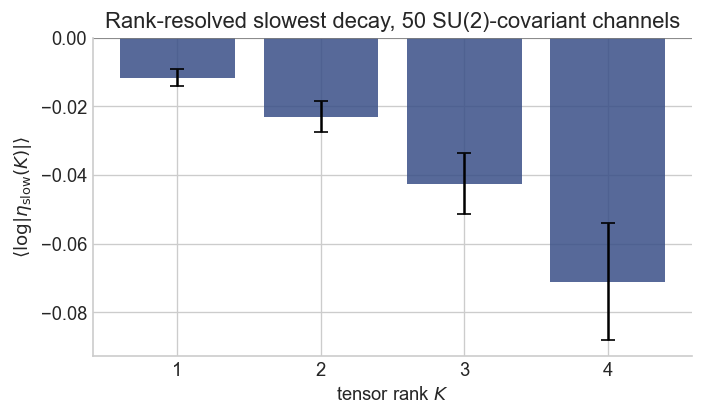

In [5]:
RANK_N_SYSTEM = 4
RANK_N_ENVIRONMENT = 2
RANK_N_TOTAL = RANK_N_SYSTEM + RANK_N_ENVIRONMENT
RANK_REALIZATIONS = 50
RANK_COUPLING_RANGE = np.pi / 5

def _rank_covariant_channel(rng):
    unitary = np.eye(2**RANK_N_TOTAL, dtype=complex)
    for coupling, sites in zip(
        rng.uniform(
            -RANK_COUPLING_RANGE,
            RANK_COUPLING_RANGE,
            RANK_N_TOTAL,
        ),
        nu.brickwork_pairs(RANK_N_TOTAL),
    ):
        unitary = (
            nu.embed_two_qubit_gate(
                nu.su2_gate(float(coupling)),
                sites,
                RANK_N_TOTAL,
            )
            @ unitary
        )
    environment_ket = nu.singlet_product(
        RANK_N_ENVIRONMENT
    )
    return nu.reduced_channel(
        unitary,
        RANK_N_SYSTEM,
        RANK_N_ENVIRONMENT,
        np.outer(
            environment_ket,
            environment_ket.conj(),
        ),
    )

rank_mode_bases = nu.su2_operator_irrep_bases(
    RANK_N_SYSTEM
)
rank_labels = sorted(
    k for k in rank_mode_bases if k > 0
)
rank_log_eta = {k: [] for k in rank_labels}
rank_covariance = {k: [] for k in rank_labels}
rank_rng = np.random.default_rng(20260728)

# Suppress the denormal-arithmetic RuntimeWarnings that
# Apple-Silicon BLAS emits when it multiplies the sparse
# rank-projector matrices. The numeric results are
# unaffected (they match a warning-free reference run).
with np.errstate(
    divide="ignore", over="ignore", invalid="ignore"
):
    for _ in range(RANK_REALIZATIONS):
        reset_channel = _rank_covariant_channel(rank_rng)
        channel_norm = la.norm(reset_channel)
        for k in rank_labels:
            basis = rank_mode_bases[k]
            projector = basis @ basis.conj().T
            rank_covariance[k].append(
                la.norm(
                    reset_channel @ projector
                    - projector @ reset_channel
                )
                / channel_norm
            )
            block = (
                basis.conj().T
                @ reset_channel
                @ basis
            )
            rank_log_eta[k].append(
                float(
                    np.log(
                        np.max(
                            np.abs(la.eigvals(block))
                        )
                    )
                )
            )

rank_mean = np.array(
    [np.mean(rank_log_eta[k]) for k in rank_labels]
)
rank_sem = np.array(
    [
        np.std(rank_log_eta[k], ddof=1)
        / np.sqrt(RANK_REALIZATIONS)
        for k in rank_labels
    ]
)

print(
    f"Ns={RANK_N_SYSTEM}, Ne={RANK_N_ENVIRONMENT}, "
    f"realizations={RANK_REALIZATIONS}"
)
print(
    "per-rank covariance error (<= 1e-12 confirms block "
    "structure):"
)
for k in rank_labels:
    print(
        f"  K={k}: {np.mean(rank_covariance[k]):.2e}"
    )

print(
    "\n<log|eta_slow(K)|> "
    "(more negative = faster ensemble decay):"
)
for k, mean, sem in zip(
    rank_labels, rank_mean, rank_sem
):
    print(
        f"  K={k}: {mean:+.4f}  (SE {sem:.4f})"
    )

rank_gaps = np.diff(rank_mean)
for k, gap in zip(rank_labels[:-1], rank_gaps):
    print(
        f"  K={k} -> K={k + 1}: "
        f"Delta<log|eta|> = {gap:+.4f}"
    )

assert np.all(
    np.array(
        [
            np.mean(rank_covariance[k])
            for k in rank_labels
        ]
    )
    < 1e-12
)
assert np.all(rank_gaps < 0)

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.bar(
    rank_labels,
    rank_mean,
    yerr=1.96 * rank_sem,
    color=BLUE,
    alpha=0.85,
    capsize=4,
)
ax.axhline(0, color="0.5", lw=0.5)
ax.set(
    xlabel=r"tensor rank $K$",
    ylabel=(
        r"$\langle\log|\eta_{\rm slow}(K)|\rangle$"
    ),
    title=(
        f"Rank-resolved slowest decay, "
        f"{RANK_REALIZATIONS} SU(2)-covariant "
        f"channels"
    ),
)
ax.set_xticks(rank_labels)
fig.tight_layout()
plt.show()


## 5. Reproduce Figure 11 from the simulation

Solid lines and 95% standard-error bands below come from the
raw 100-realization simulation.


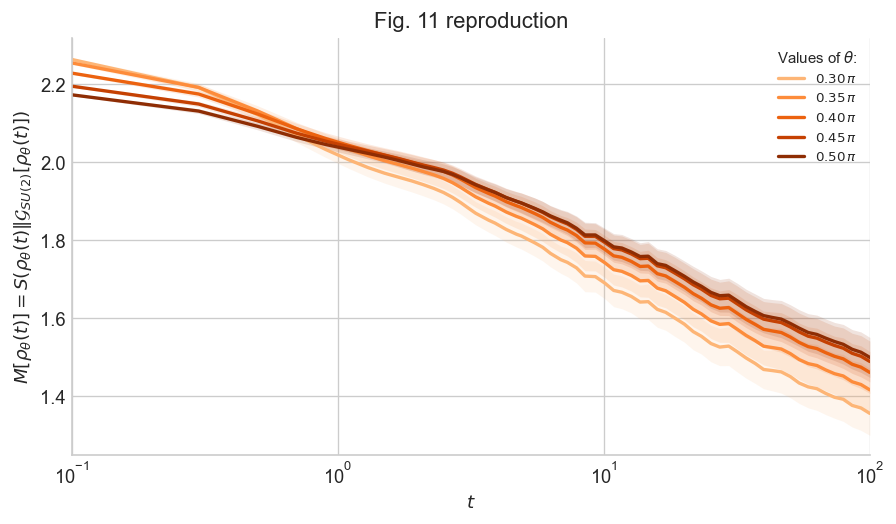

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 4.5))
for curve, error, label, color in zip(
    mean_asymmetry,
    sem_asymmetry,
    labels,
    PALETTE_5,
):
    ax.plot(
        displayed_time,
        curve,
        color=color,
        lw=2.0,
        label=label,
    )
    ax.fill_between(
        displayed_time,
        curve - 1.96 * error,
        curve + 1.96 * error,
        color=color,
        alpha=0.13,
        linewidth=0,
    )
ax.set(
    xscale="log",
    xlim=(0.1, 100.1),
    ylim=(1.25, 2.32),
    xlabel=r"$t$",
    ylabel=(
        r"$M[\rho_\theta(t)]"
        r"=S(\rho_\theta(t)\Vert\mathcal{G}_{SU(2)}"
        r"[\rho_\theta(t)])$"
    ),
    title="Fig. 11 reproduction",
)
ax.legend(
    title=r"Values of $\theta$:",
    fontsize=8,
    title_fontsize=9,
)
fig.tight_layout()
plt.show()

assert np.all(np.isfinite(mean_asymmetry))
assert np.all(sem_asymmetry >= 0)


## 6. Pairwise Mpemba crossings

Figure 11 reverses the ordering of all five initial conditions.
The table measures the first crossing of every pair directly from
the simulated ensemble mean, using only linear interpolation
between adjacent simulated time samples.


In [7]:
def first_crossing(x, first, second):
    difference = np.asarray(first) - np.asarray(second)
    exact = np.flatnonzero(np.isclose(difference, 0, atol=1e-13))
    sign_changes = np.flatnonzero(
        difference[:-1] * difference[1:] < 0
    )
    candidates = []
    candidates.extend(float(x[index]) for index in exact)
    candidates.extend(
        float(
            x[index]
            - difference[index]
            * (x[index + 1] - x[index])
            / (
                difference[index + 1]
                - difference[index]
            )
        )
        for index in sign_changes
    )
    return min(candidates) if candidates else np.nan


crossing_rows = []
for later_index in range(1, len(theta_over_pi)):
    for earlier_index in range(later_index):
        crossing_rows.append((
            theta_over_pi[later_index],
            theta_over_pi[earlier_index],
            first_crossing(
                displayed_time,
                mean_asymmetry[later_index],
                mean_asymmetry[earlier_index],
            ),
        ))

print("theta_later  theta_earlier  first simulated crossing")
for later, earlier, crossing in crossing_rows:
    print(
        f"    {later:.2f}pi"
        f"         {earlier:.2f}pi"
        f"              {crossing:.6f}"
    )

crossing_times = np.array(
    [row[2] for row in crossing_rows]
)
print(
    "crossing-time range:",
    crossing_times.min(),
    "to",
    crossing_times.max(),
)

assert len(crossing_rows) == 10
assert np.all(np.isfinite(crossing_times))
assert np.all(
    mean_asymmetry[:-1, 0]
    > mean_asymmetry[1:, 0]
)
assert np.all(
    mean_asymmetry[:-1, -1]
    < mean_asymmetry[1:, -1]
)


theta_later  theta_earlier  first simulated crossing
    0.35pi         0.30pi              0.296105
    0.40pi         0.30pi              0.482112
    0.40pi         0.35pi              0.708419
    0.45pi         0.30pi              0.651373
    0.45pi         0.35pi              0.935469
    0.45pi         0.40pi              1.458448
    0.50pi         0.30pi              0.761146
    0.50pi         0.35pi              1.114940
    0.50pi         0.40pi              2.526198
    0.50pi         0.45pi              4.284793
crossing-time range: 0.2961049184642981 to 4.284792654884507


## Convention audit and result

The simulation reproduces the five Figure 11 curves and their ten
pairwise ordering reversals with a genuine SU(2)-covariant
non-Markovian circuit.

Two figure-era conventions are made explicit because they are not
documented by the manuscript's printed equations or public raw
data:

- the curve labels $\theta/\pi=0.30,\ldots,0.50$ correspond to
  the tilt
  $$
  |\varphi_\theta\rangle
  =\cos[(\theta+\pi/2)/2]|\xi\rangle^{\otimes N_s/2}
  +\sin[(\theta+\pi/2)/2]|0\rangle^{\otimes N_s};
  $$
- the displayed axis uses
  $t=0.1+0.2(\text{Floquet layer}-1)$.

These conventions are documented explicitly because they are
not stated in the manuscript's printed equations or its public
raw data. The physics calculation itself is full SU(2):
isotropic gates, invariant singlet bath, all total-spin sectors,
and the exact non-Abelian Haar twirl. The numerical commutator
tests above make that distinction executable.
